# Building a Simple GPT-Style Q&A LLM from Scratch

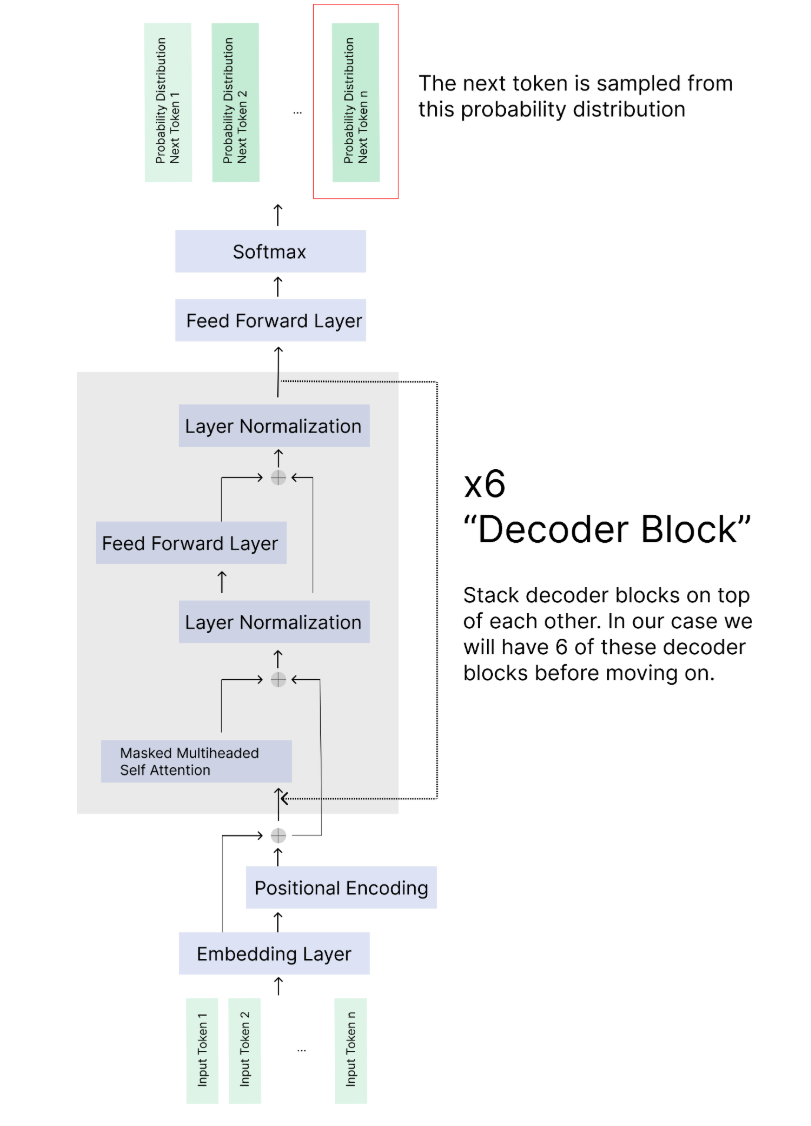

2 Steps
- Pretraining: self supervised learning task, where parts of the input data are omitted and used as target variables
- Supervised fine tuning: works similar to traditional supervised learning tasks, with human annoted labels for input data.

# 1. Pretraining

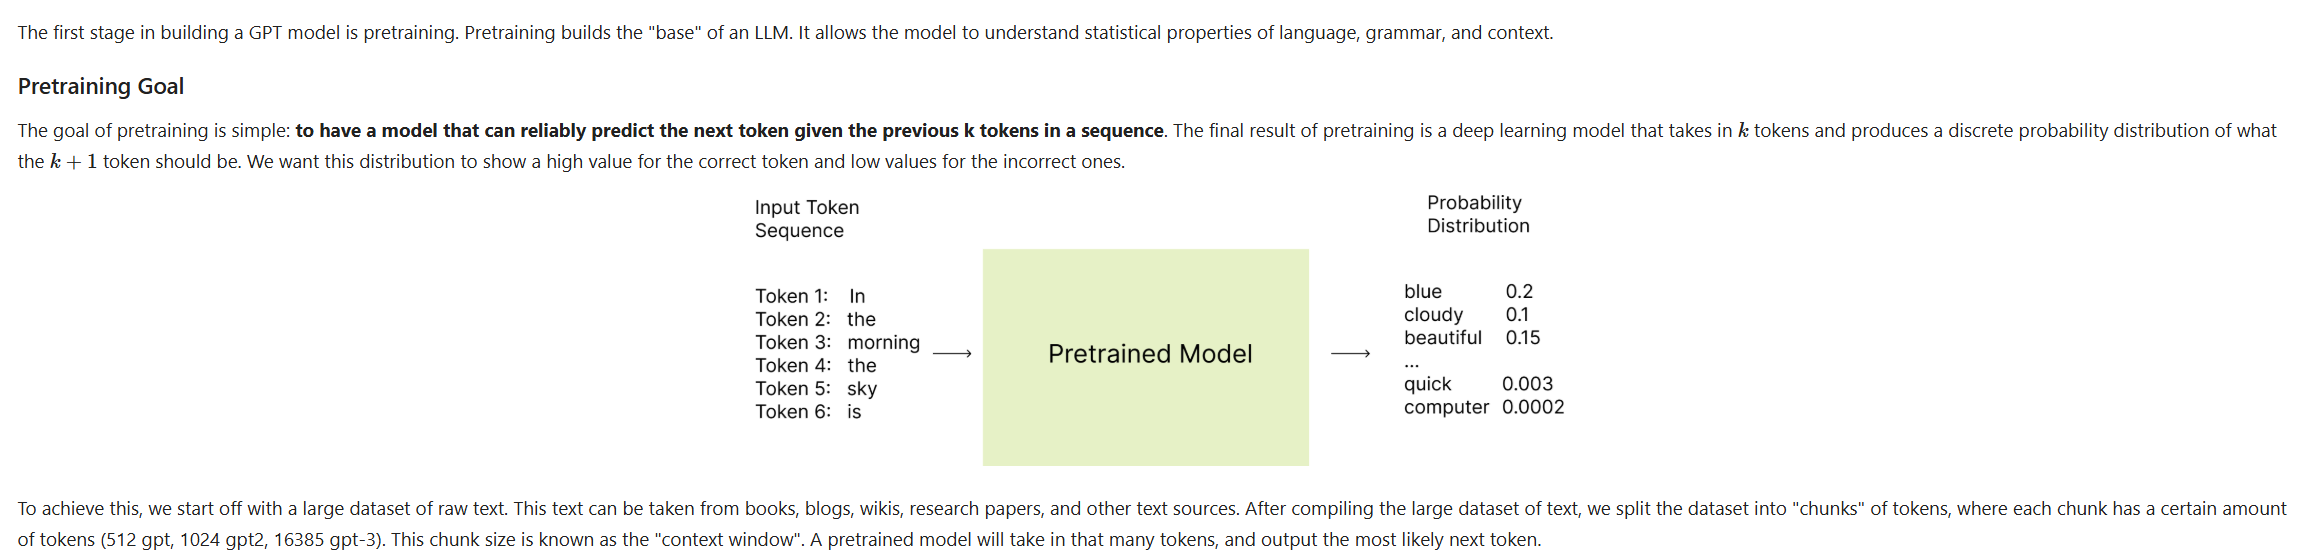

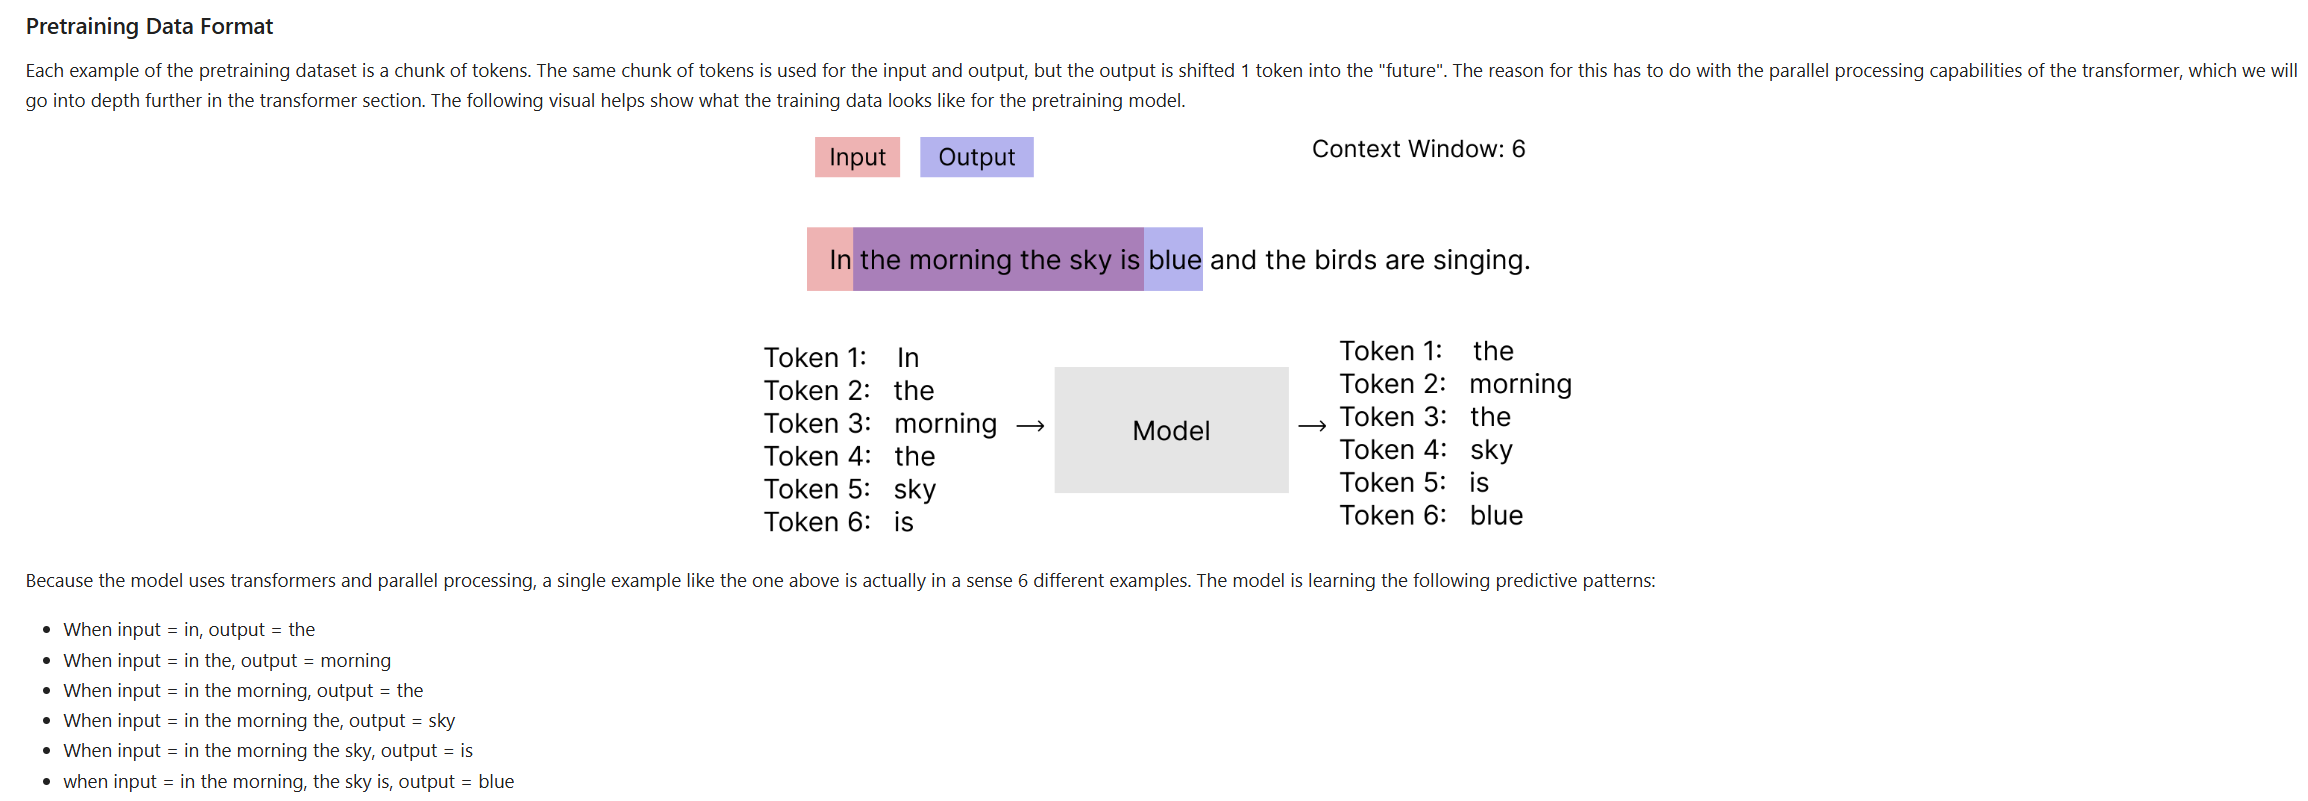

## 1.1 Download Data

Data - https://huggingface.co/datasets/EleutherAI/wikitext_document_level

In [1]:
import warnings
import torch
import math
import time
import os
import matplotlib.pyplot as plt
from itertools import cycle
from datasets import Dataset
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from pathlib import Path
import json

from torch.optim.lr_scheduler import _LRScheduler
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

c:\Users\deril\OneDrive\Desktop\Deril\Development\Transformers-From-Scratch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [3]:
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

from datasets import load_dataset
dataset = load_dataset("EleutherAI/wikitext_document_level", "wikitext-2-raw-v1", split="train")

## 1.2 Tokenize and Chunk

For pretraining language models, a simple approach to tokenizing and chunking text is as follows:

- Concatenate all the text into one giant "blob". This means you have one large string.
- Tokenize the whole blob into one list of tokens. At this point you have one large array of integers.
- Chunk the tokens into fixed size blocks (1024, 2048, larger...) (this is the "context window"). At this point you have multiple arrays of integers, each of the same length (context size).


This process will change slightly when using datasets that are too large to fit into memory.

In [4]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print("Vocabulary size:", tokenizer.n_vocab) # Vocabilary size is how many unique tokens the tokenizer can encode
print("End of text token:", tokenizer.eot_token) # End of text token is used to indicate the end of a text sequence
print("Example tokenization:", tokenizer.encode("Hello world!"))

Vocabulary size: 50257
End of text token: 50256
Example tokenization: [15496, 995, 0]


In [5]:
all_text = ""
all_data = dataset["page"]
for example in all_data:
    all_text += "<page> "+ example + " </page>"

# Tokenize the entire text at once
tokenized_text = tokenizer.encode(all_text)
print("Total number of tokens:", len(tokenized_text))
print("First 10 tokens:", tokenized_text[:10])

Total number of tokens: 2420931
First 10 tokens: [27, 7700, 29, 220, 796, 569, 18354, 7496, 17740, 6711]


In [6]:
def get_dataset(num_examples, context_window_length, test_split=0.1):
    input_blocks = [] # List to store input sequences
    target_blocks = [] # List to store target sequences

    # Use a sliding window to create input/target sequences
    for i in range(0, len(tokenized_text), context_window_length + 1):
        block = tokenized_text[i:i+context_window_length+ 1]
        
        # Skip blocks that are too short
        if len(block) < context_window_length + 1:
            continue

        input_seq = block[:-1]  
        target_seq = block[1:]  

        input_blocks.append(input_seq)
        target_blocks.append(target_seq)
        
        # Stop if we have enough examples
        if len(input_blocks) >= num_examples:
            break

    # Convert to tensors for pytorch and move to gpu
    inputs = torch.tensor(input_blocks, dtype=torch.long).to(device)
    targets = torch.tensor(target_blocks, dtype=torch.long).to(device)

    # Calculate train/test split point
    split_idx = int(num_examples * (1 - test_split))

    # Split into train/test
    train_inputs = inputs[:split_idx]
    train_targets = targets[:split_idx]
    test_inputs = inputs[split_idx:]
    test_targets = targets[split_idx:]
    return train_inputs, train_targets, test_inputs, test_targets

- B = batch size → number of sequences processed together  
- T = sequence length → number of tokens in each sequence (context window)

#### Transformer Batching (Pre-training)

- Inputs:  (B, T)
- Targets: (B, T)

Targets are inputs shifted by 1:

Input:  [x₁, x₂, x₃, x₄]  
Target: [x₂, x₃, x₄, x₅]

Model predicts next token at **every position**:
→ total predictions = B × T

Key idea: predict all tokens in parallel, not one-by-one.

In [7]:
i, o, _, _ = get_dataset(2, 4, 0)
print("Input Shape", i.shape)
print("Output Shape", o.shape)
print("Input Example:")
print(i)
print("Output Example:")
print(o)

Input Shape torch.Size([2, 4])
Output Shape torch.Size([2, 4])
Input Example:
tensor([[   27,  7700,    29,   220],
        [  569, 18354,  7496, 17740]], device='cuda:0')
Output Example:
tensor([[ 7700,    29,   220,   796],
        [18354,  7496, 17740,  6711]], device='cuda:0')


## 1.3 LLM

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# A simple configuration container
class GPTConfig:
    def __init__(
        self, 
        vocab_size,  # size of the vocabulary, from tokenizer, for gpt2 tokenizer it is 50257
        n_layer,   # number of transformer blocks
        n_head,    # number of attention heads for each transformer block
        n_embd,  # embedding dimension for each token
        seq_len,  # sequence length for the model - e.g. the "context window" 
    
    ):
        self.vocab_size = vocab_size
        self.n_layer = n_layer
        self.n_head = n_head
        self.n_embd = n_embd
        self.seq_len = seq_len
     
test_config = GPTConfig(
    vocab_size=tokenizer.n_vocab,
    n_layer=2,  
    n_head=3,
    n_embd=6,
    seq_len=4,
)
test_config

### 1.3.1 Token Embedding Layer

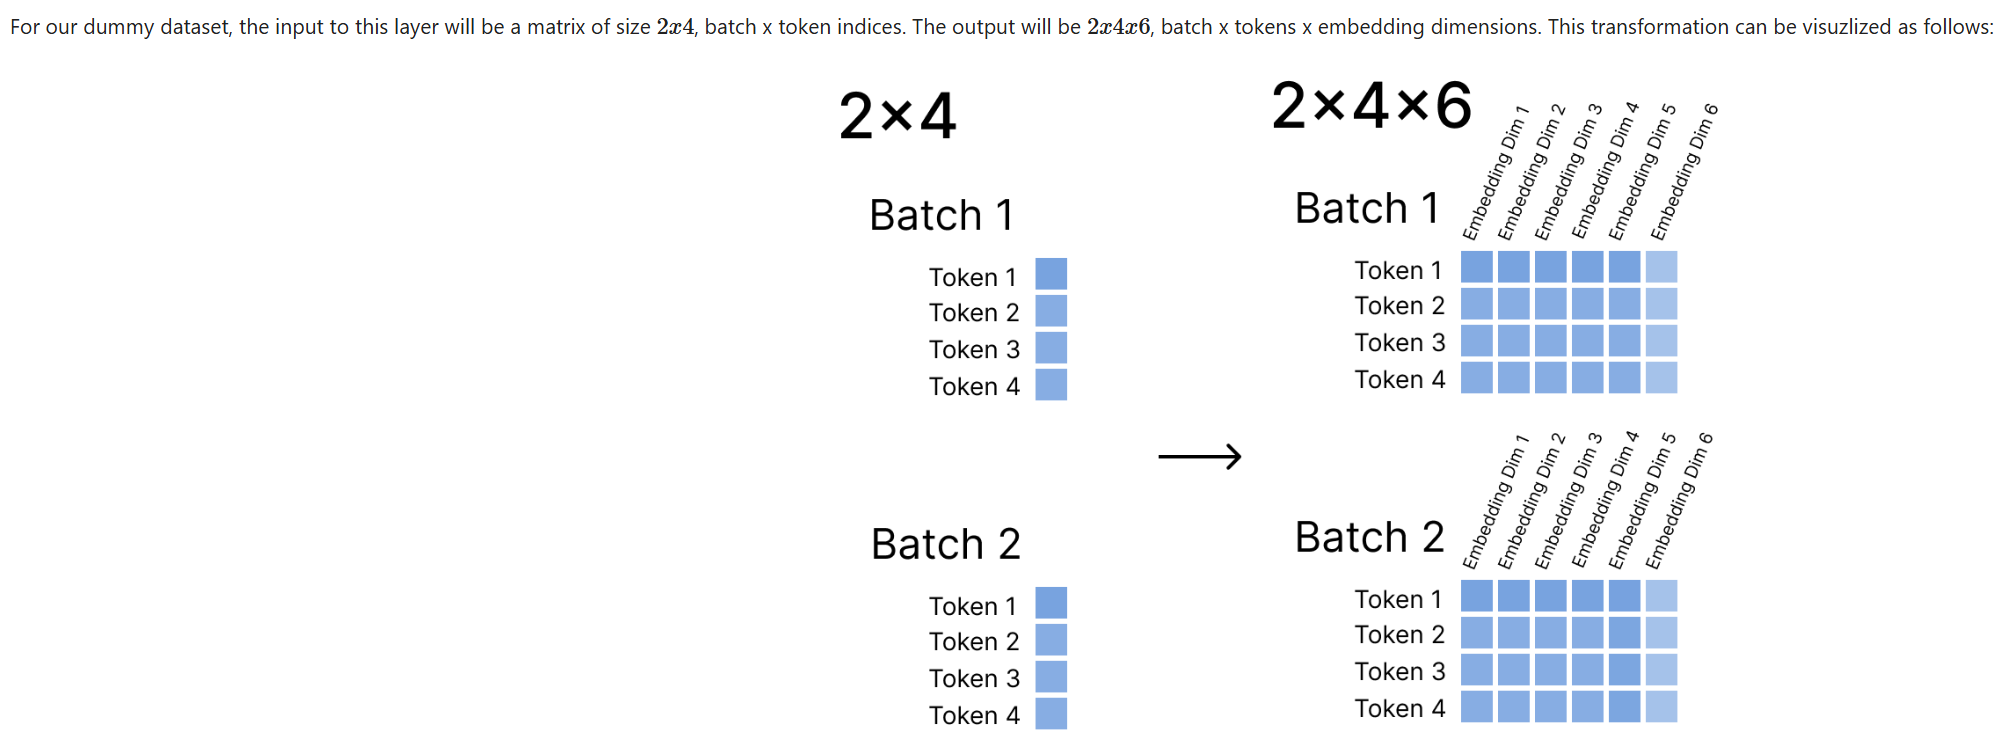

Embedding vectors are randomly initialized at start of the training

Embeddings are trained jointly with the model

In [9]:
token_embedding = nn.Embedding(test_config.vocab_size, test_config.n_embd).to(device)
test_batch_inputs, _, _, _ = get_dataset(2, test_config.seq_len, 0)
print("Batch shape:", test_batch_inputs.shape, "Batch x Seq Len")
print("After embedding:", token_embedding(test_batch_inputs).shape, "Batch x Seq Len x Embedding Dim")
print("")
print("Before embedding")
print(test_batch_inputs)
print("After embedding")
print(token_embedding(test_batch_inputs))

Batch shape: torch.Size([2, 4]) Batch x Seq Len
After embedding: torch.Size([2, 4, 6]) Batch x Seq Len x Embedding Dim

Before embedding
tensor([[   27,  7700,    29,   220],
        [  569, 18354,  7496, 17740]], device='cuda:0')
After embedding
tensor([[[-0.1906, -1.1785,  1.0764, -0.3327,  1.4467, -0.3263],
         [-1.6187,  0.0848, -1.2470,  0.2359, -1.3517, -0.3079],
         [-0.8897, -1.1929, -0.7278,  1.1637,  1.3619,  0.6436],
         [-0.3556, -0.6722, -0.6455,  1.2009, -0.5948, -1.1928]],

        [[ 0.5013, -0.9620,  0.3665, -0.4067,  0.1770, -1.0966],
         [ 0.5215, -1.6000,  1.1477,  0.2347,  2.0778, -0.4512],
         [-0.1821, -2.0015,  2.0089,  0.6312,  0.1451, -0.3643],
         [-0.5424,  0.5108, -0.9168,  0.0366, -0.4527,  0.5323]]],
       device='cuda:0', grad_fn=<EmbeddingBackward0>)


### 1.3.2 Position Embedding Layer

In [10]:
def get_position_encoding(seq_len, d, n=10000):
    """
    Computes the positional encoding matrix of shape (seq_len, d).
    
    Args:
        seq_len (int): Length of the sequence.
        d (int): Dimension of the embedding.
        n (float): The base for the exponential term (default 10000 in many Transformer implementations).
    
    Returns:
        torch.Tensor: A tensor of shape (seq_len, d) containing the positional encodings.
    """
    
    P = torch.zeros(seq_len, d).to(device)
    for pos in range(seq_len):
        for i in range(0, d // 2):
            P[pos, 2 * i] = math.sin(pos / (n ** ((2 * i) / d)))
            if i + 1 < d:
                P[pos, 2* i + 1] = math.cos(pos / (n ** ((2 * i) / d)))

    return P.unsqueeze(0)


# Example usage:
position_encoding = get_position_encoding(seq_len=test_config.seq_len, d=test_config.n_embd)
print("Position encoding shape:", position_encoding.shape)

Position encoding shape: torch.Size([1, 4, 6])


In [11]:
test_embeddings = token_embedding(test_batch_inputs)
test_embeddings_with_pos = test_embeddings + position_encoding
print("Token embeddings shape:", test_embeddings.shape)
print("Position encodings shape:", position_encoding.shape)
print("Sum of token embeddings and position encodings:",test_embeddings_with_pos.shape)

Token embeddings shape: torch.Size([2, 4, 6])
Position encodings shape: torch.Size([1, 4, 6])
Sum of token embeddings and position encodings: torch.Size([2, 4, 6])


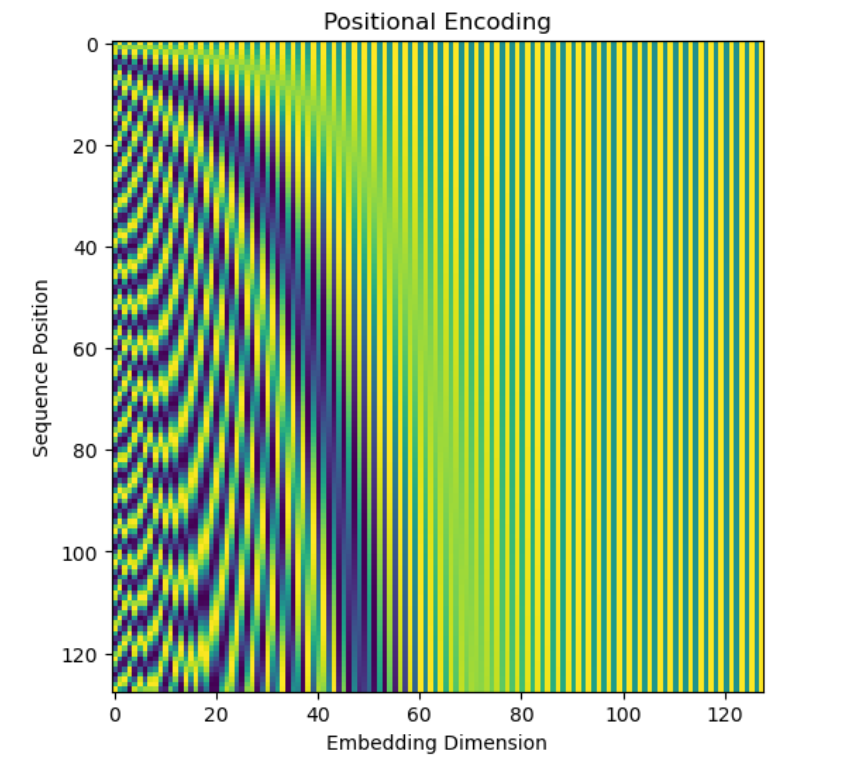

### 1.3.3 Self Attention Code

In [12]:
class SelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Wq = nn.Parameter(torch.randn(config.n_embd, config.n_embd)).to(device) # Query weights - will transform input embeddings into queries
        self.Wk = nn.Parameter(torch.randn(config.n_embd, config.n_embd)).to(device) # Key weights - will transform input embeddings into keys
        self.Wv = nn.Parameter(torch.randn(config.n_embd, config.n_embd)).to(device) # Value weights - will transform input embeddings into values

    def forward(self, x):
        print("Attention input shape:", x.shape)
        print("")
        print("Query weights shape:", self.Wq.shape)
        print("Key weights shape:", self.Wk.shape)
        print("Value weights shape:", self.Wv.shape)
        queries = x @ self.Wq # Matrix multiplication to transform input embeddings into queries
        keys = x @ self.Wk # Matrix multiplication to transform input embeddings into keys
        values = x @ self.Wv # Matrix multiplication to transform input embeddings into values
        print("")
        print("Queries shape:", queries.shape)
        print("Keys shape:", keys.shape)
        print("Values shape:", values.shape)

        qkt = queries @ keys.transpose(-2, -1) # Calculate QK^T
        qkt_scaled = qkt / math.sqrt(queries.size(-1)) # Scale QK^T by the dimension of the keys
        qkt_softmax = F.softmax(qkt_scaled, dim=-1) # Apply softmax row-wise to get attention weights
        print("")
        print("QK^T shape:", qkt.shape)

        attn_output = qkt_softmax @ values # Multiply softmax(QK^T) by values
        print("")
        print("Attention output shape:", attn_output.shape)
        return attn_output 

attention = SelfAttention(test_config)
test_out = attention(test_embeddings_with_pos)

Attention input shape: torch.Size([2, 4, 6])

Query weights shape: torch.Size([6, 6])
Key weights shape: torch.Size([6, 6])
Value weights shape: torch.Size([6, 6])

Queries shape: torch.Size([2, 4, 6])
Keys shape: torch.Size([2, 4, 6])
Values shape: torch.Size([2, 4, 6])

QK^T shape: torch.Size([2, 4, 4])

Attention output shape: torch.Size([2, 4, 6])


### 1.3.4 Causal Self Attention

In [13]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Wq = nn.Parameter(torch.randn(config.n_embd, config.n_embd)).to(device) # Query weights - will transform input embeddings into queries
        self.Wk = nn.Parameter(torch.randn(config.n_embd, config.n_embd)).to(device) # Key weights - will transform input embeddings into keys
        self.Wv = nn.Parameter(torch.randn(config.n_embd, config.n_embd)).to(device) # Value weights - will transform input embeddings into values

    def forward(self, x):
        seq_len = x.shape[1] # Get sequence length (number of tokens / context window length)
        queries = x @ self.Wq # Matrix multiplication to transform input embeddings into queries
        keys = x @ self.Wk    # Matrix multiplication to transform input embeddings into keys
        values = x @ self.Wv  # Matrix multiplication to transform input embeddings into values
        qkt = queries @ keys.transpose(-2, -1)  # Calculate QK^T
        qkt_scaled = qkt / math.sqrt(queries.size(-1))  # Scale QK^T by the dimension of the keys

        # MASKING
        # THIS IS THE ONLY DIFFERENCE, USE -inf FOR UPPER TRIANGLE MASK SO THAT SOFTMAX WILL BE 0
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1)
        causal_mask = causal_mask.masked_fill(causal_mask == 1, float('-inf'))  # Upper triangle masked with -inf 
        qkt_scaled = qkt_scaled + causal_mask # Add the mask to the scaled QK^T
        # END MASKING

        qkt_softmax = F.softmax(qkt_scaled, dim=-1) # Apply softmax row-wise to get attention weights, the -inf values will become 0 here
        attn_output = qkt_softmax @ values # Multiply softmax(QK^T) by values
        return attn_output


attention = CausalSelfAttention(test_config)
test_out = attention(test_embeddings_with_pos)
print(test_out.shape)  # Output should have shape: (batch_size, seq_len, n_embd)

torch.Size([2, 4, 6])


### 1.3.5 Multi-head Causal Attention

In [14]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0, "n_embd must be divisible by n_head"

        self.n_head = config.n_head # 3
        self.n_embd = config.n_embd # 6
        self.head_dim = config.n_embd // config.n_head # 2, this is the dimension of each attention head

        self.Wqkv = nn.Linear(self.n_embd, 3 * self.n_embd, bias=False).to(device) # 6x18
        self.proj = nn.Linear(self.n_embd, self.n_embd, bias=False).to(device) # 6x6

        # Causal mask to ensure that attention is only applied to previous tokens in the sequence
        mask = torch.tril(
            torch.ones(config.seq_len, config.seq_len, device=device, dtype=torch.bool) # 4x4
        )
        self.register_buffer("causal_mask", mask.view(1, 1, config.seq_len, config.seq_len))

    def forward(self, x):
        B, seq_len, n_embd = x.shape  # (batch, time, channels) = (2, 4, 6)

        # 1) Multiply input by Wqkv to get queries, keys, values
        qkv = self.Wqkv(x)  # (B, seq_len, 3n_embd)

        # 2) Split the Q, K, V matrices
        q, k, v = qkv.split(n_embd, dim=2)  # each (B, seq_len, n_embd)
     
        # 3) Reshape the Q, K, V Matrices Into Heads
        #    (B,T,C) -> (B, seq_len, n_head, head_dim) -> (B, n_head, seq_len, head_dim)
        q = q.view(B, seq_len, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, seq_len, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, seq_len, self.n_head, self.head_dim).transpose(1, 2)
      

        # 4) QK^T
        #    (B, n_head, seq_len, seq_len)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # 5) Mask Before Softmax
        mask = self.causal_mask[:, :, :seq_len, :seq_len]
        att = att.masked_fill(~mask, float("-inf"))

        # 6) Softmax & Multiply by V
        #    (B, n_head, seq_len, head_dim)
        att = F.softmax(att, dim=-1)
        y = att @ v        

        # 7) Merge heads: 
        #    (B, n_head, seq_len, head_dim) -> (B, seq_len, embedding_dim)
        y = y.transpose(1, 2).contiguous().view(B, seq_len, n_embd)

        # 8) Projection Layer 
        y = self.proj(y)
        return y

multihead_attn = MultiHeadAttention(test_config)
test_out = multihead_attn(test_embeddings_with_pos)
print(test_out.shape)  # Output should have shape: (batch_size, seq_len, n_embd)

torch.Size([2, 4, 6])


### 1.3.6 The Block

In [15]:
class GPTBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.mha = MultiHeadAttention(config)
        self.ln1 = nn.LayerNorm(config.n_embd).to(device)
        self.ffn = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
        ).to(device)
        self.ln2 = nn.LayerNorm(config.n_embd).to(device)

    def forward(self, x):
        x = x + self.mha(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

block = GPTBlock(test_config)
test_out = block(test_embeddings_with_pos)
print(test_out.shape)  # Output should have shape: (batch_size, seq_len, n_embd)

torch.Size([2, 4, 6])


### 1.4 Full Model

In [16]:
class GPTModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embedding = nn.Embedding(config.vocab_size, config.n_embd).to(device)
        self.position_encoding = get_position_encoding(config.seq_len, config.n_embd)
        self.blocks = nn.Sequential(*[GPTBlock(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd).to(device)
        self.head = nn.Linear(config.n_embd, config.vocab_size).to(device)
    
    def forward(self, x):
        x = self.token_embedding(x) + self.position_encoding
        x = self.blocks(x)
        x = self.ln_f(x)
        return self.head(x)
    
gpt = GPTModel(test_config)
print(test_batch_inputs.shape)
test_out = gpt(test_batch_inputs)
print(test_out.shape) 

torch.Size([2, 4])
torch.Size([2, 4, 50257])


### 1.5 Testing (Dummy Training)

#### 1.5.1 Overfitting

In [17]:
# Example config:
batch_size = 10
sequence_len = 128
num_steps = 1000
train_inputs, train_targets, _, _ = get_dataset(10, sequence_len, 0)
config = GPTConfig(
    vocab_size=tokenizer.n_vocab,
    n_layer=4,   # fewer layers for a quick demo; no of transformer blocks
    n_head=4, # no of attention heads for each transformer block
    n_embd=128, # embedding dimension for each token
    seq_len=sequence_len, # context window length
)


# Create the GPT model
model = GPTModel(config)

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# Define Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',factor=0.2, patience=20, min_lr=5e-6, threshold=1e-4)

# Training loop
i = 1
losses = []

while i < num_steps:
    for j in range(0, len(train_inputs), batch_size): # runs only once since we have 10 examples and batch size is 10
        x = train_inputs[j:j+batch_size] # (10, 128) (B, T)
        y = train_targets[j:j+batch_size] # (10, 128) (B, T)

        # Forward pass
        logits = model(x) # (10, 128, vocab_size)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # prevent exploding gradients by clipping them to a maximum norm of 1.0

        losses.append(loss.item())
        
        optimizer.step() # Update model parameters based on the computed gradients
        optimizer.zero_grad() # Clear gradients for the next step
    

        loss = loss.item() # Get the scalar value of the loss for logging and scheduler
        scheduler.step(loss) # Update the learning rate based on the loss, if the loss does not improve for 'patience' number of steps, the learning rate will be reduced by a factor of 0.2 until it reaches the minimum learning rate of 5e-6.

   
        # Print the average loss for the epoch
        lr = optimizer.param_groups[0]["lr"] # Get the current learning rate from the optimizer for logging
        print(f"Step {i+1}/{num_steps}, Loss: {loss}, LR: {lr}")

        i += 1

Step 2/1000, Loss: 10.99048137664795, LR: 0.0005
Step 3/1000, Loss: 10.774574279785156, LR: 0.0005
Step 4/1000, Loss: 10.57409954071045, LR: 0.0005
Step 5/1000, Loss: 10.392072677612305, LR: 0.0005
Step 6/1000, Loss: 10.22877311706543, LR: 0.0005
Step 7/1000, Loss: 10.081889152526855, LR: 0.0005
Step 8/1000, Loss: 9.947443962097168, LR: 0.0005
Step 9/1000, Loss: 9.821053504943848, LR: 0.0005
Step 10/1000, Loss: 9.69890022277832, LR: 0.0005
Step 11/1000, Loss: 9.57809066772461, LR: 0.0005
Step 12/1000, Loss: 9.456573486328125, LR: 0.0005
Step 13/1000, Loss: 9.332919120788574, LR: 0.0005
Step 14/1000, Loss: 9.206184387207031, LR: 0.0005
Step 15/1000, Loss: 9.075825691223145, LR: 0.0005
Step 16/1000, Loss: 8.94171142578125, LR: 0.0005
Step 17/1000, Loss: 8.804276466369629, LR: 0.0005
Step 18/1000, Loss: 8.664712905883789, LR: 0.0005
Step 19/1000, Loss: 8.52503776550293, LR: 0.0005
Step 20/1000, Loss: 8.387661933898926, LR: 0.0005
Step 21/1000, Loss: 8.254183769226074, LR: 0.0005
Step 22/1

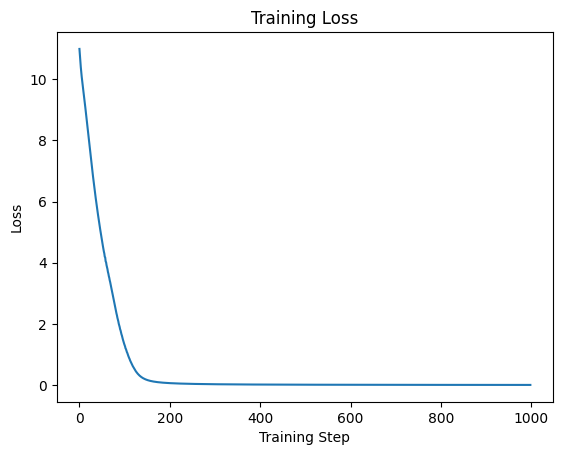

In [18]:
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

Why does this Overfit?

We have a very small dataset (10 examples) and a relatively large model (4 layers, 4 heads, 128 embedding dimension) which gives the model a lot of capacity to memorize the training data. With such a small dataset, the model can easily learn to predict the training examples perfectly, leading to overfitting. Additionally, we are training for 1000 steps which is quite long for such a small dataset, allowing the model to further fit the training data closely.

Total model params: ~10M+

In [19]:
def inference(prompt, max_new_tokens):
    tokens = tokenizer.encode(prompt)
    for _ in range(max_new_tokens): # auto-regressive generation loop, runs for the number of new tokens we want to generate
        num_tokens = len(tokens)
        tokens_padded = tokens + [tokenizer.eot_token] * (config.seq_len - num_tokens) # model expects a fixed sequence length=128, so we pad the input tokens with the end of text token until we reach the context window length
        tokens_padded = torch.tensor(tokens_padded).unsqueeze(0).to(device) # 1, 128
        logits = model(tokens_padded) # (1, T, vocab_size)
        predicted_token = torch.argmax(logits[0, num_tokens-1, :]).item()
        tokens.append(predicted_token)
    return tokenizer.decode(tokens)
    
print("Original: ", tokenizer.decode(train_inputs[2].tolist())[:90])
print("Predicted:", inference(" director Takeshi Ozawa . A large team of writers handled the script", max_new_tokens=6))

Original:   director Takeshi Ozawa . A large team of writers handled the script . The game 's opening
Predicted:  director Takeshi Ozawa . A large team of writers handled the script . The game 's opening


In [20]:
print("Predicted:", inference(" hello, how are", max_new_tokens=6))
# bad output    

Predicted:  hello, how are the game . 
 The


### 1.6 Real Training

This code builds a GPT-style training dataset from raw CNN/DailyMail articles. It streams the dataset, tokenizes each article using a GPT-2 tokenizer, and accumulates tokens in a buffer. From this continuous stream, it creates fixed-length chunks (e.g., 128 tokens) where each input sequence is paired with a target sequence shifted by one token—so the model learns to predict the next token at every position. It generates a large number of such input–target pairs, splits them into train and test sets, and saves them as parquet files so the preprocessing only needs to be done once.

In [21]:
# Load dataset in streaming mode
ds = load_dataset("abisee/cnn_dailymail", "3.0.0", split="train")
hf_tokenizer = AutoTokenizer.from_pretrained("gpt2") # efficiently tokenize on the fly without loading the entire dataset into memory

def check_dataset_exists():
    try:
        # Attempt to load the dataset with reuse_cache_if_exists mode
        load_dataset("parquet", data_files="cnn_dailymail_train.parquet", split="train")
        load_dataset("parquet", data_files="cnn_dailymail_test.parquet", split="train")
        return True
    except FileNotFoundError:
        return False
    
if not check_dataset_exists():
    print("Tokenized dataset does not exist locally... Generating and saving to disk.")

    def tokenize_and_chunk(dataset, tokenizer, chunk_size=512, train_rows=100_000, test_rows=500):
        """
        Tokenizes and chunks the dataset into fixed-length 512-token segments.
        The 'target' sequence is shifted left by 1 token.
        Stops after generating `train_rows + test_rows` tokenized chunks.
        """
        buffer = []  # Rolling buffer for tokens
        row_count = 0

        for example in dataset:
            tokens = tokenizer(example["article"], truncation=False, padding=False)['input_ids']
            buffer.extend(tokens)

            # Yield full chunks until we reach train_rows + test_rows
            while len(buffer) >= chunk_size + 1:  # +1 to ensure we can shift target
                if row_count >= (train_rows + test_rows):
                    return  # Stop yielding once enough rows are reached

                # Create input-target pairs
                input_chunk = buffer[:chunk_size]         # First 512 tokens
                target_chunk = buffer[1:chunk_size + 1]  # Shifted by 1 token
                
                # Assign to train or test split
                split = "train" if row_count < train_rows else "test"

                yield {
                    "split": split,
                    "input": input_chunk, 
                    "target": target_chunk
                }
                
                buffer = buffer[chunk_size:]  # Remove used tokens
                row_count += 1

    # Set the max number of rows for training and testing
    TRAIN_ROWS = 1400000  # Adjust as needed
    TEST_ROWS = 500   # Adjust as needed
    CHUNK_SIZE = 128

    # Convert generator to a Hugging Face Dataset
    tokenized_ds = Dataset.from_generator(lambda: tokenize_and_chunk(ds, hf_tokenizer,chunk_size=CHUNK_SIZE, train_rows=TRAIN_ROWS, test_rows=TEST_ROWS))

    # Split the dataset into `train` and `test`
    dataset_splits = tokenized_ds.train_test_split(test_size=TEST_ROWS / (TRAIN_ROWS + TEST_ROWS), seed=42)

    # Save to disk
    dataset_splits["train"].to_parquet("cnn_dailymail_train.parquet")
    dataset_splits["test"].to_parquet("cnn_dailymail_test.parquet")

    print(f"✅ Saved {TRAIN_ROWS} train rows and {TEST_ROWS} test rows.")
else:
    print("Tokenized dataset already exists locally.")

Tokenized dataset already exists locally.


In [22]:
# Example config:
from anyio.lowlevel import checkpoint


batch_size = 64
sequence_len = 128
num_steps = 150000
accumulation_steps = 100

torch.cuda.empty_cache()

# Reload the train and test datasets
train_ds = load_dataset("parquet", data_files="cnn_dailymail_train.parquet", split="train")
test_ds = load_dataset("parquet", data_files="cnn_dailymail_test.parquet", split="train")

# Convert dataset to PyTorch format
train_ds.set_format("torch", columns=["input", "target"])
test_ds.set_format("torch", columns=["input", "target"])

# Create DataLoaders for training and testing
train_dataloader = cycle(DataLoader(train_ds, batch_size=batch_size, shuffle=False))
test_dataloader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

config = GPTConfig(
    vocab_size=hf_tokenizer.vocab_size,
    n_layer=8,   # fewer layers for a quick demo
    n_head=8,
    n_embd=128,
    seq_len=sequence_len,
)

# Create the GPT model
model = GPTModel(config)
model = model.to(device)
model_path = Path(r"C:\Users\deril\OneDrive\Desktop\Deril\Development\Transformers-From-Scratch\aca_pretraining\model_run\model\pretrain_final.pth")
# Check if pre-trained model exists
use_existing_model = True
if use_existing_model:
    checkpoint = torch.load(model_path, map_location=device)
    saved_config = checkpoint["model_config"]
    config = GPTConfig(
        vocab_size=saved_config["vocab_size"],
        seq_len=saved_config["seq_len"],
        n_layer=saved_config["n_layer"],
        n_head=saved_config["n_head"],
        n_embd=saved_config["n_embd"],
    )

    model = GPTModel(config).to(device)
    model.load_state_dict(checkpoint["model_state_dict"], strict=False) # strict=False allows loading a checkpoint that may have missing or extra keys compared to the model architecture, useful if we made changes to the model after saving the checkpoint   
    model.eval()

    print("Loaded pre-trained model from ./pretrain_final.pth, skipping training loop.")
    print(f"Saved step: {checkpoint.get('step')}")

else:
    # Define the optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)


    # Define Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',factor=0.3, patience=10, min_lr=5e-6, threshold=1e-4)


    # Training loop
    losses = []
    test_losses = []
    accumulator = 0
    accumulator_loss = 0
    start_time = time.time()
    for i in range(num_steps):
        model.train()
        example = next(train_dataloader)
        train_input = example["input"].to(device)
        train_target = example["target"].to(device)

        logits = model(train_input)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), train_target.view(-1))
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()
        optimizer.zero_grad()

        accumulator += 1
        accumulator_loss += loss.item()

        
        if accumulator >= accumulation_steps:
            losses.append(accumulator_loss / accumulation_steps)
            accumulator = 0
            accumulator_loss = 0
            model.eval()
            test_loss = 0
            test_accumulator = 0
            with torch.no_grad():
                for test_example in test_dataloader:
                    test_input = test_example["input"].to(device)
                    test_target = test_example["target"].to(device)
                    test_logits = model(test_input)
                    test_loss += F.cross_entropy(test_logits.view(-1, test_logits.size(-1)), test_target.view(-1)).item()
                    test_accumulator += 1
                test_losses.append(test_loss / test_accumulator)
                elapsed_time = time.time() - start_time
                print(f"Step {i+1}/{num_steps}, Loss: {losses[-1]}, Test Loss: {test_losses[-1]}, LR: {optimizer.param_groups[0]['lr']}, Elapsed Time: {elapsed_time:.2f} seconds")
                test_dataloader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
                scheduler.step(test_losses[-1])

   
        if (i+1) % 50000 == 0:
            # Save the model checkpoint
            print(f"Saving model checkpoint at step {i+1}")
            torch.save(model, f"./model_checkpoint_{i}.pt")

Loaded pre-trained model from ./pretrain_final.pth, skipping training loop.
Saved step: 150000


Ran on ACA Job with GPU - See more detais in aca_pretraining/ folder

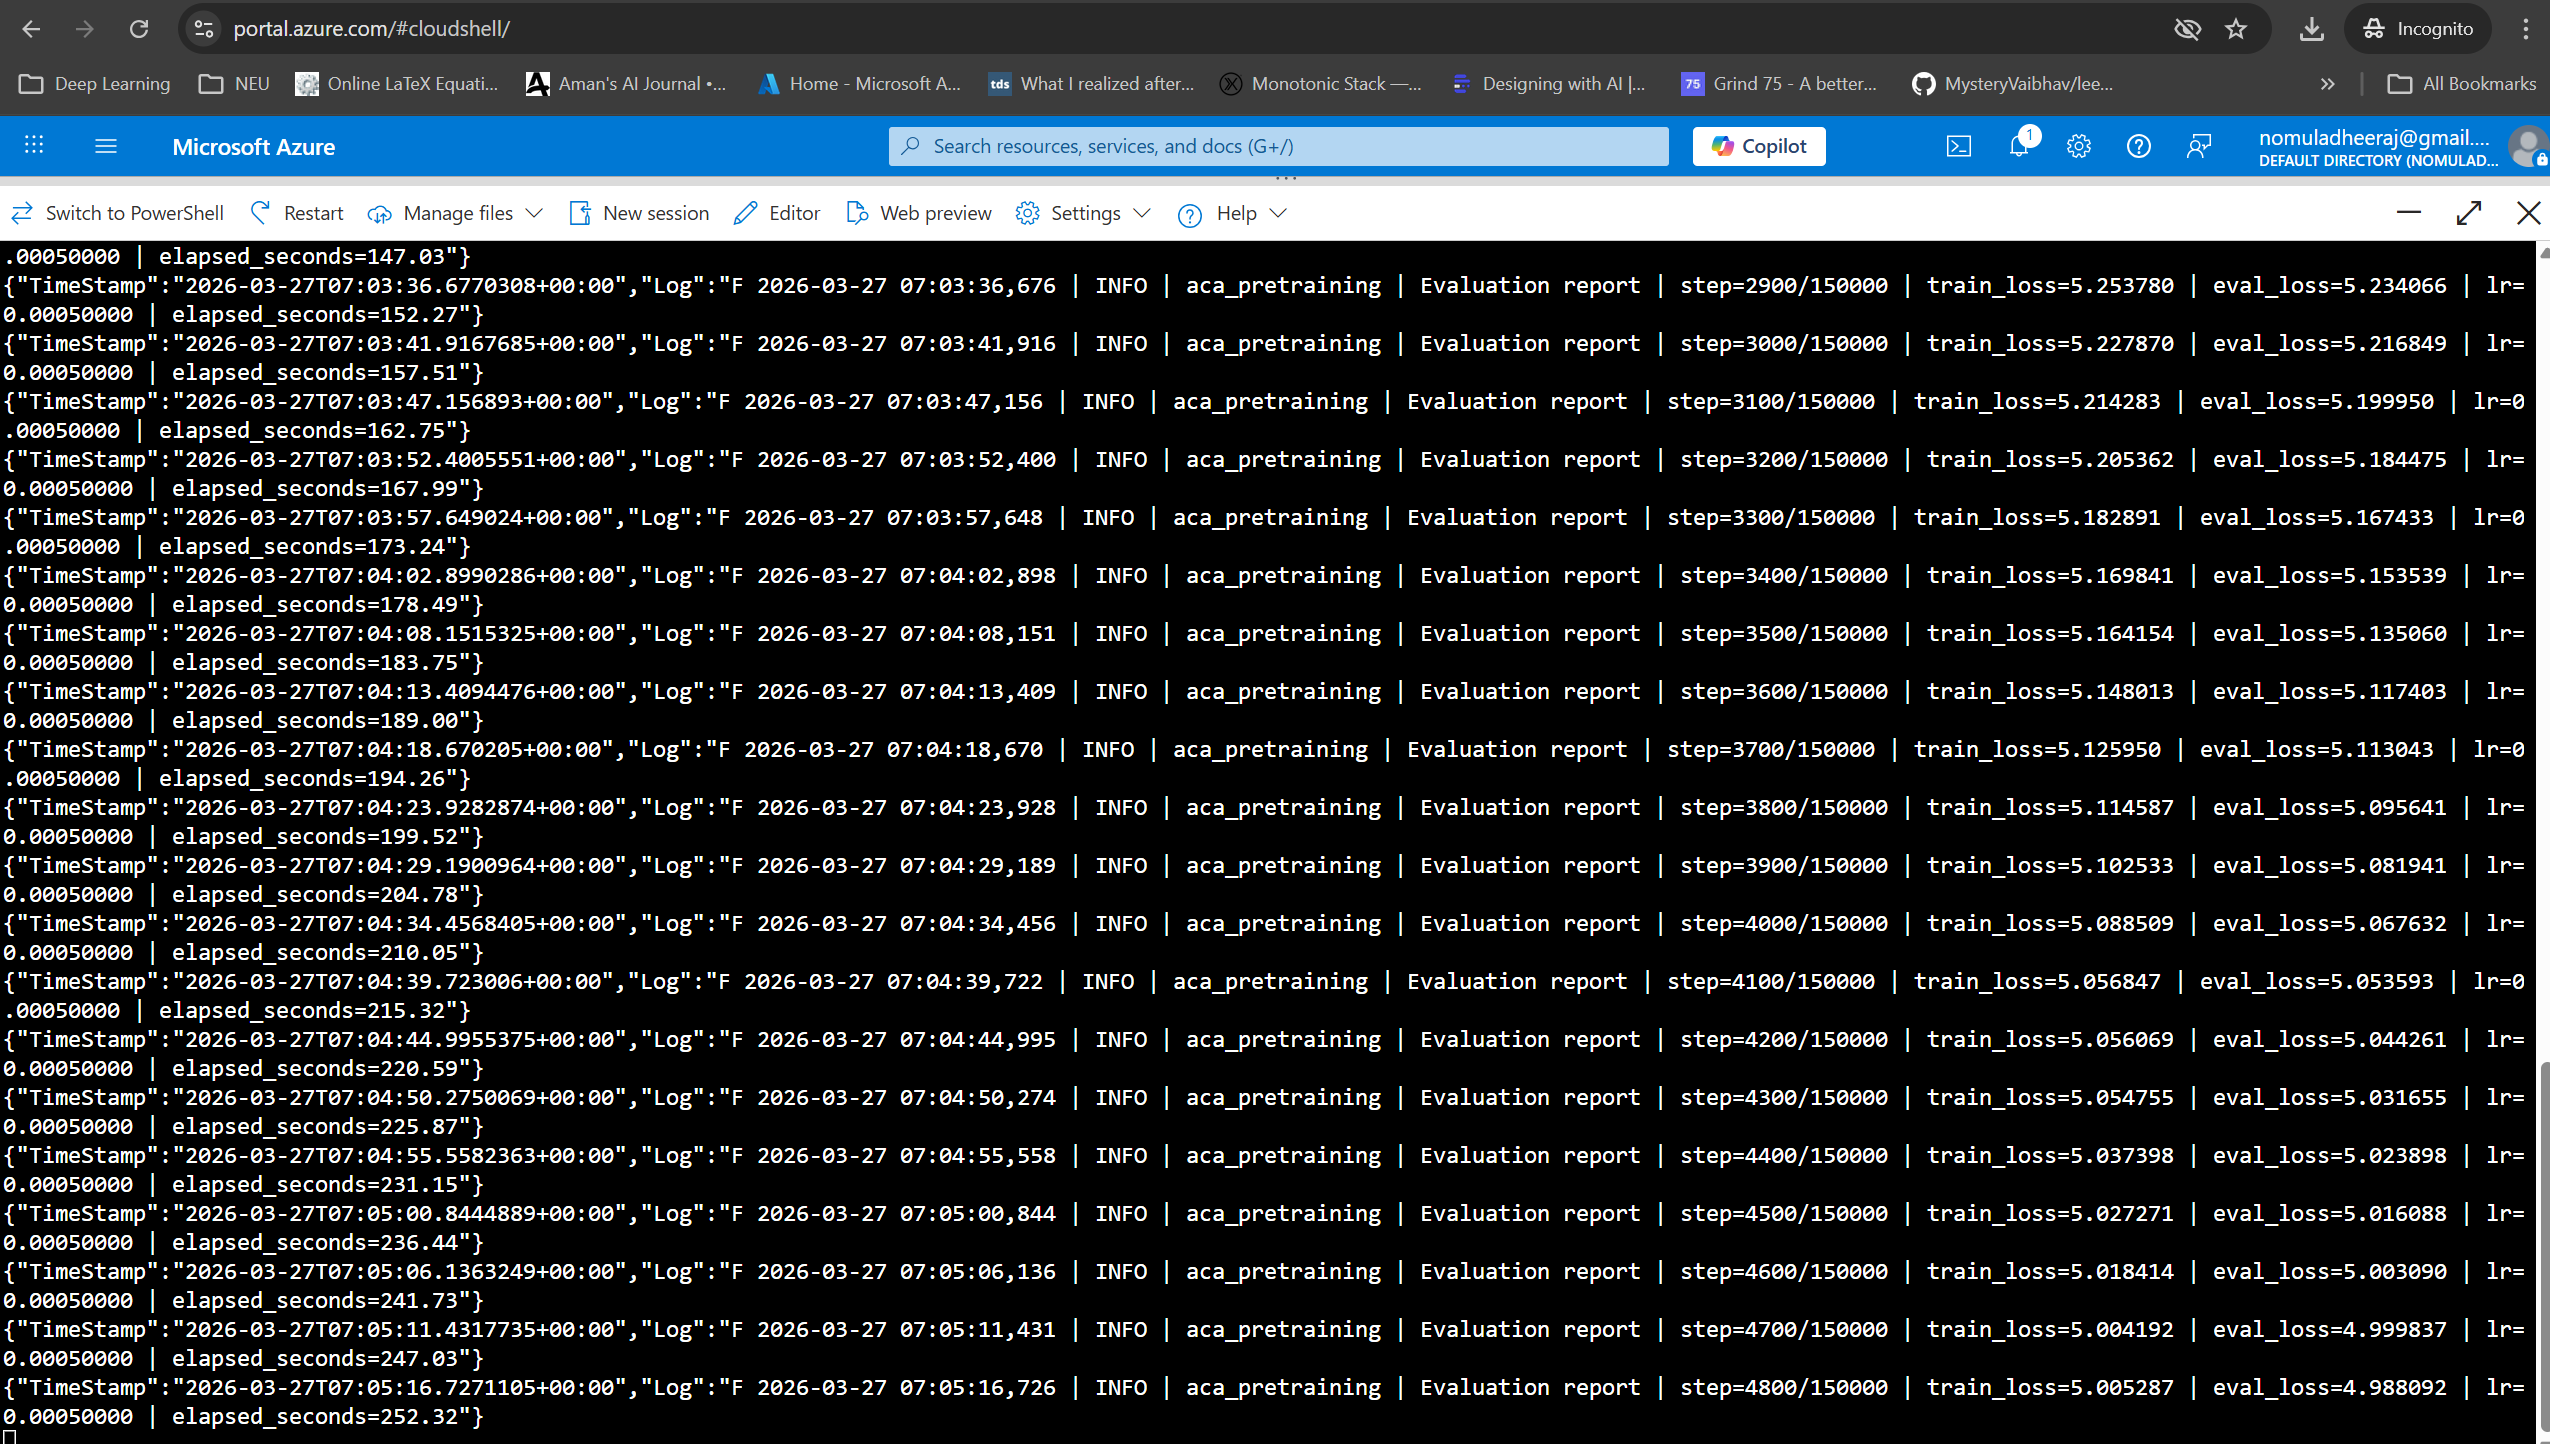

#### Load model and metadata from Blob Storage after ACA Run

In [23]:
model_run_dir = Path(r"C:\Users\deril\OneDrive\Desktop\Deril\Development\Transformers-From-Scratch\aca_pretraining\model_run")
metrics_path = model_run_dir / "metrics" / "metrics.json"
loss_curve_path = model_run_dir / "metrics" / "loss_curve.png"

use_existing_model = metrics_path.exists()

if not use_existing_model:
    raise FileNotFoundError(f"Could not find metrics file at {metrics_path}")

with open(metrics_path, "r", encoding="utf-8") as f:
    metrics = json.load(f)

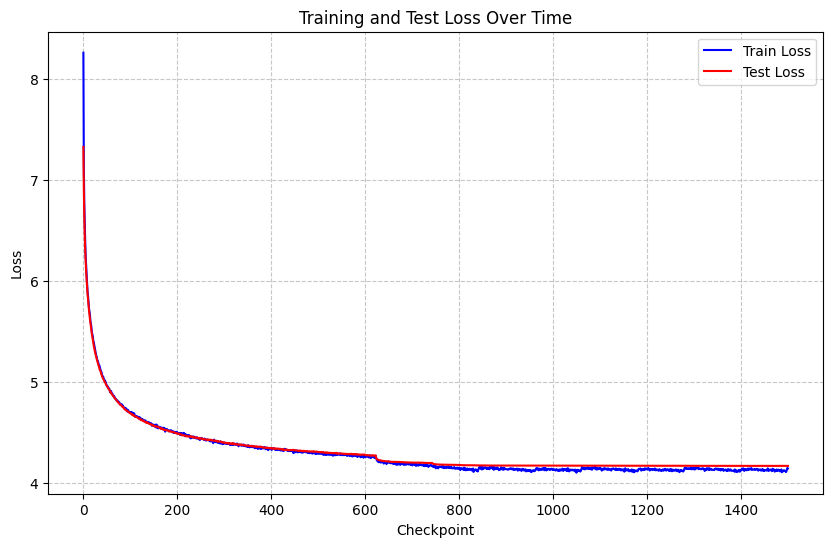

In [24]:
train_losses = [item["loss"] for item in metrics["train_losses"]]
test_losses = [item["loss"] for item in metrics["eval_losses"]]

if loss_curve_path.exists():
    print("Existing model used, showing saved loss curve.")
    plt.figure(figsize=(10, 6))
    plt.imshow(plt.imread(loss_curve_path))
    plt.axis("off")
else:
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label="Train Loss", color="blue")
    plt.plot(test_losses, label="Test Loss", color="red")
    plt.xlabel("Checkpoint")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Over Time")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()
    plt.show()

#### 1.6.1 Inference

In [25]:
def inference(prompt,torch_model, max_new_tokens):
    torch_model.eval()
    with torch.no_grad():
        tokens = hf_tokenizer.encode(prompt)
        for _ in range(max_new_tokens):
            num_tokens = len(tokens)
            tokens_padded = tokens + [hf_tokenizer.eos_token_id] * (config.seq_len - num_tokens)
            tokens_padded = torch.tensor(tokens_padded).unsqueeze(0).to(device)
            logits = torch_model(tokens_padded)
            probabilities = torch.softmax(logits[0, num_tokens-1, :], dim=-1)
            predicted_token = torch.multinomial(probabilities, 1).item()
            tokens.append(predicted_token)
        return hf_tokenizer.decode(tokens)

In [26]:
print("Predicted:", inference("The president signed a bill to pass", model, max_new_tokens=20))
print("Predicted:", inference("There was a large division in", model, max_new_tokens=20))
print("Predicted:", inference("Reports are showing that", model, max_new_tokens=20))

Predicted: The president signed a bill to pass the ceiling of his private university and decided to rename, everywhere and accord, but for the first time
Predicted: There was a large division in the remaining regions in the United States. "I think people in Texas don't risk our country from
Predicted: Reports are showing that the organization supports all sized and more than 1,100 commanders from the U.S. in several


### 1.7 Supervised Fine Tuning

In [29]:
import os

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

import huggingface_hub.constants as hf_constants
hf_constants.HF_HUB_ENABLE_HF_TRANSFER = False

from datasets import load_dataset

sft_ds = load_dataset("rubenroy/GammaCorpus-Fact-QA-450k", split="train", streaming=True)


def check_sft_dataset_exists():
    try:
        # Attempt to load the dataset with reuse_cache_if_exists mode
        load_dataset("parquet", data_files="fact_qa_train.parquet", split="train")
        load_dataset("parquet", data_files="fact_qa_test.parquet", split="train")
        return True
    except FileNotFoundError:
        return False
    
if not check_sft_dataset_exists():
    print("Tokenized supervised fine tuning dataset does not exist locally... Generating and saving to disk.")

    def tokenize_and_chunk(dataset, tokenizer, chunk_size=512, rows=1000):
        """
        Tokenizes and chunks the dataset into fixed-length 512-token segments.
        The 'target' sequence is shifted left by 1 token.
        Stops after generating `train_rows + test_rows` tokenized chunks.
        """
        row_count = 0

        for example in dataset:
            question_plus_answer = "<Question>" + example["question"] + "</Question>" + "<Answer>" + example["answer"] + "</Answer>"
            input_tokens = tokenizer(question_plus_answer, truncation=False, padding=False)['input_ids']

            if row_count >= rows:
                return

            if len(input_tokens) >= chunk_size:
                continue
            else:
                input_tokens = input_tokens +[tokenizer.eos_token_id] * (chunk_size - len(input_tokens))
            
            target_tokens = input_tokens[1:] + [tokenizer.eos_token_id]  # Shifted by 1 token

            yield {
                "input": input_tokens, 
                "target": target_tokens
            }
            
            row_count += 1

    # Set the max number of rows for training and testing
    TRAIN_ROWS = 440000  # Adjust as needed
    TEST_ROWS = 500   # Adjust as needed
    CHUNK_SIZE = 128

    # Convert generator to a Hugging Face Dataset
    tokenized_sft_dataset = Dataset.from_generator(lambda: tokenize_and_chunk(sft_ds, hf_tokenizer,chunk_size=CHUNK_SIZE, rows=TRAIN_ROWS + TEST_ROWS))

    # Split the dataset into `train` and `test`
    sft_dataset_splits = tokenized_sft_dataset.train_test_split(train_size=TRAIN_ROWS, test_size=TEST_ROWS, seed=42)

    # Save to disk
    sft_dataset_splits["train"].to_parquet("fact_qa_train.parquet")
    sft_dataset_splits["test"].to_parquet("fact_qa_test.parquet")

    print(f"✅ Saved {TRAIN_ROWS} train rows and {TEST_ROWS} test rows for supervised fine tuning.")
else:
    print("SFT Tokenized dataset already exists locally.")

Tokenized supervised fine tuning dataset does not exist locally... Generating and saving to disk.


Generating train split: 440500 examples [01:43, 4268.03 examples/s]
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 84.95ba/s]

✅ Saved 440000 train rows and 500 test rows for supervised fine tuning.


In [30]:
# Example config:
batch_size = 64
sequence_len = 128
num_steps = 50000
accumulation_steps = 100

# Reload the train and test datasets
train_ds = load_dataset("parquet", data_files="fact_qa_train.parquet", split="train")
test_ds = load_dataset("parquet", data_files="fact_qa_test.parquet", split="train")

# Convert dataset to PyTorch format
train_ds.set_format("torch", columns=["input", "target"])
test_ds.set_format("torch", columns=["input", "target"])

# Create DataLoaders for training and testing
train_dataloader = cycle(DataLoader(train_ds, batch_size=batch_size, shuffle=False))
test_dataloader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


# use_existing_model = os.path.exists("./sft_final.pth")
# Check if pre-trained model exists
sft_model_path = Path(
    r"C:\Users\deril\OneDrive\Desktop\Deril\Development\Transformers-From-Scratch\aca_sft\model_run\model\sft_final.pth"
)

use_existing_model = sft_model_path.exists()

if use_existing_model:
    checkpoint = torch.load(sft_model_path, map_location=device)

    saved_config = checkpoint["model_config"]
    config = GPTConfig(
        vocab_size=saved_config["vocab_size"],
        seq_len=saved_config["seq_len"],
        n_layer=saved_config["n_layer"],
        n_head=saved_config["n_head"],
        n_embd=saved_config["n_embd"],
    )

    model = GPTModel(config).to(device)

    state_dict = checkpoint["model_state_dict"].copy()
    state_dict.pop("position_encoding", None)

    model.load_state_dict(state_dict, strict=False)
    model.eval()

    print(f"Loaded fine tuned model from {sft_model_path}, skipping training loop.")
    print(f"Saved step: {checkpoint.get('step')}")

else:
    # For SFT we start with the pretrained model
    model = torch.load("./pretrain_final.pth", weights_only=False)
    
    # Define the optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)


    # Scheduler with dynamic step size
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',factor=0.2, patience=10, min_lr=5e-6, threshold=1e-4)


    # Training loop
    losses = []
    test_losses = []
    accumulator = 0
    accumulator_loss = 0
    for i in range(num_steps):
        model.train()
        example = next(train_dataloader)
        train_input = example["input"].to(device)
        train_target = example["target"].to(device)
        logits = model(train_input)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), train_target.view(-1))
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()
        optimizer.zero_grad()

        accumulator += 1
        accumulator_loss += loss.item()

        

        if accumulator >= accumulation_steps:
            losses.append(accumulator_loss / accumulation_steps)
            accumulator = 0
            accumulator_loss = 0
            model.eval()
            test_loss = 0
            test_accumulator = 0
            with torch.no_grad():
                for test_example in test_dataloader:
                    test_input = test_example["input"].to(device)
                    test_target = test_example["target"].to(device)
                    test_logits = model(test_input)
                    test_loss += F.cross_entropy(test_logits.view(-1, test_logits.size(-1)), test_target.view(-1)).item()
                    test_accumulator += 1
                test_losses.append(test_loss / test_accumulator)
                print(f"Step {i+1}/{num_steps}, Loss: {losses[-1]}, Test Loss: {test_losses[-1]}")
                test_dataloader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
                scheduler.step(test_losses[-1])

        if i+1 % 50000 == 0:
            torch.save(model.state_dict(), f"./sft_model_checkpoint_{i}.pt")

Generating train split: 440000 examples [00:00, 461248.44 examples/s]
Generating train split: 500 examples [00:00, ? examples/s]


Loaded fine tuned model from C:\Users\deril\OneDrive\Desktop\Deril\Development\Transformers-From-Scratch\aca_sft\model_run\model\sft_final.pth, skipping training loop.
Saved step: 50000


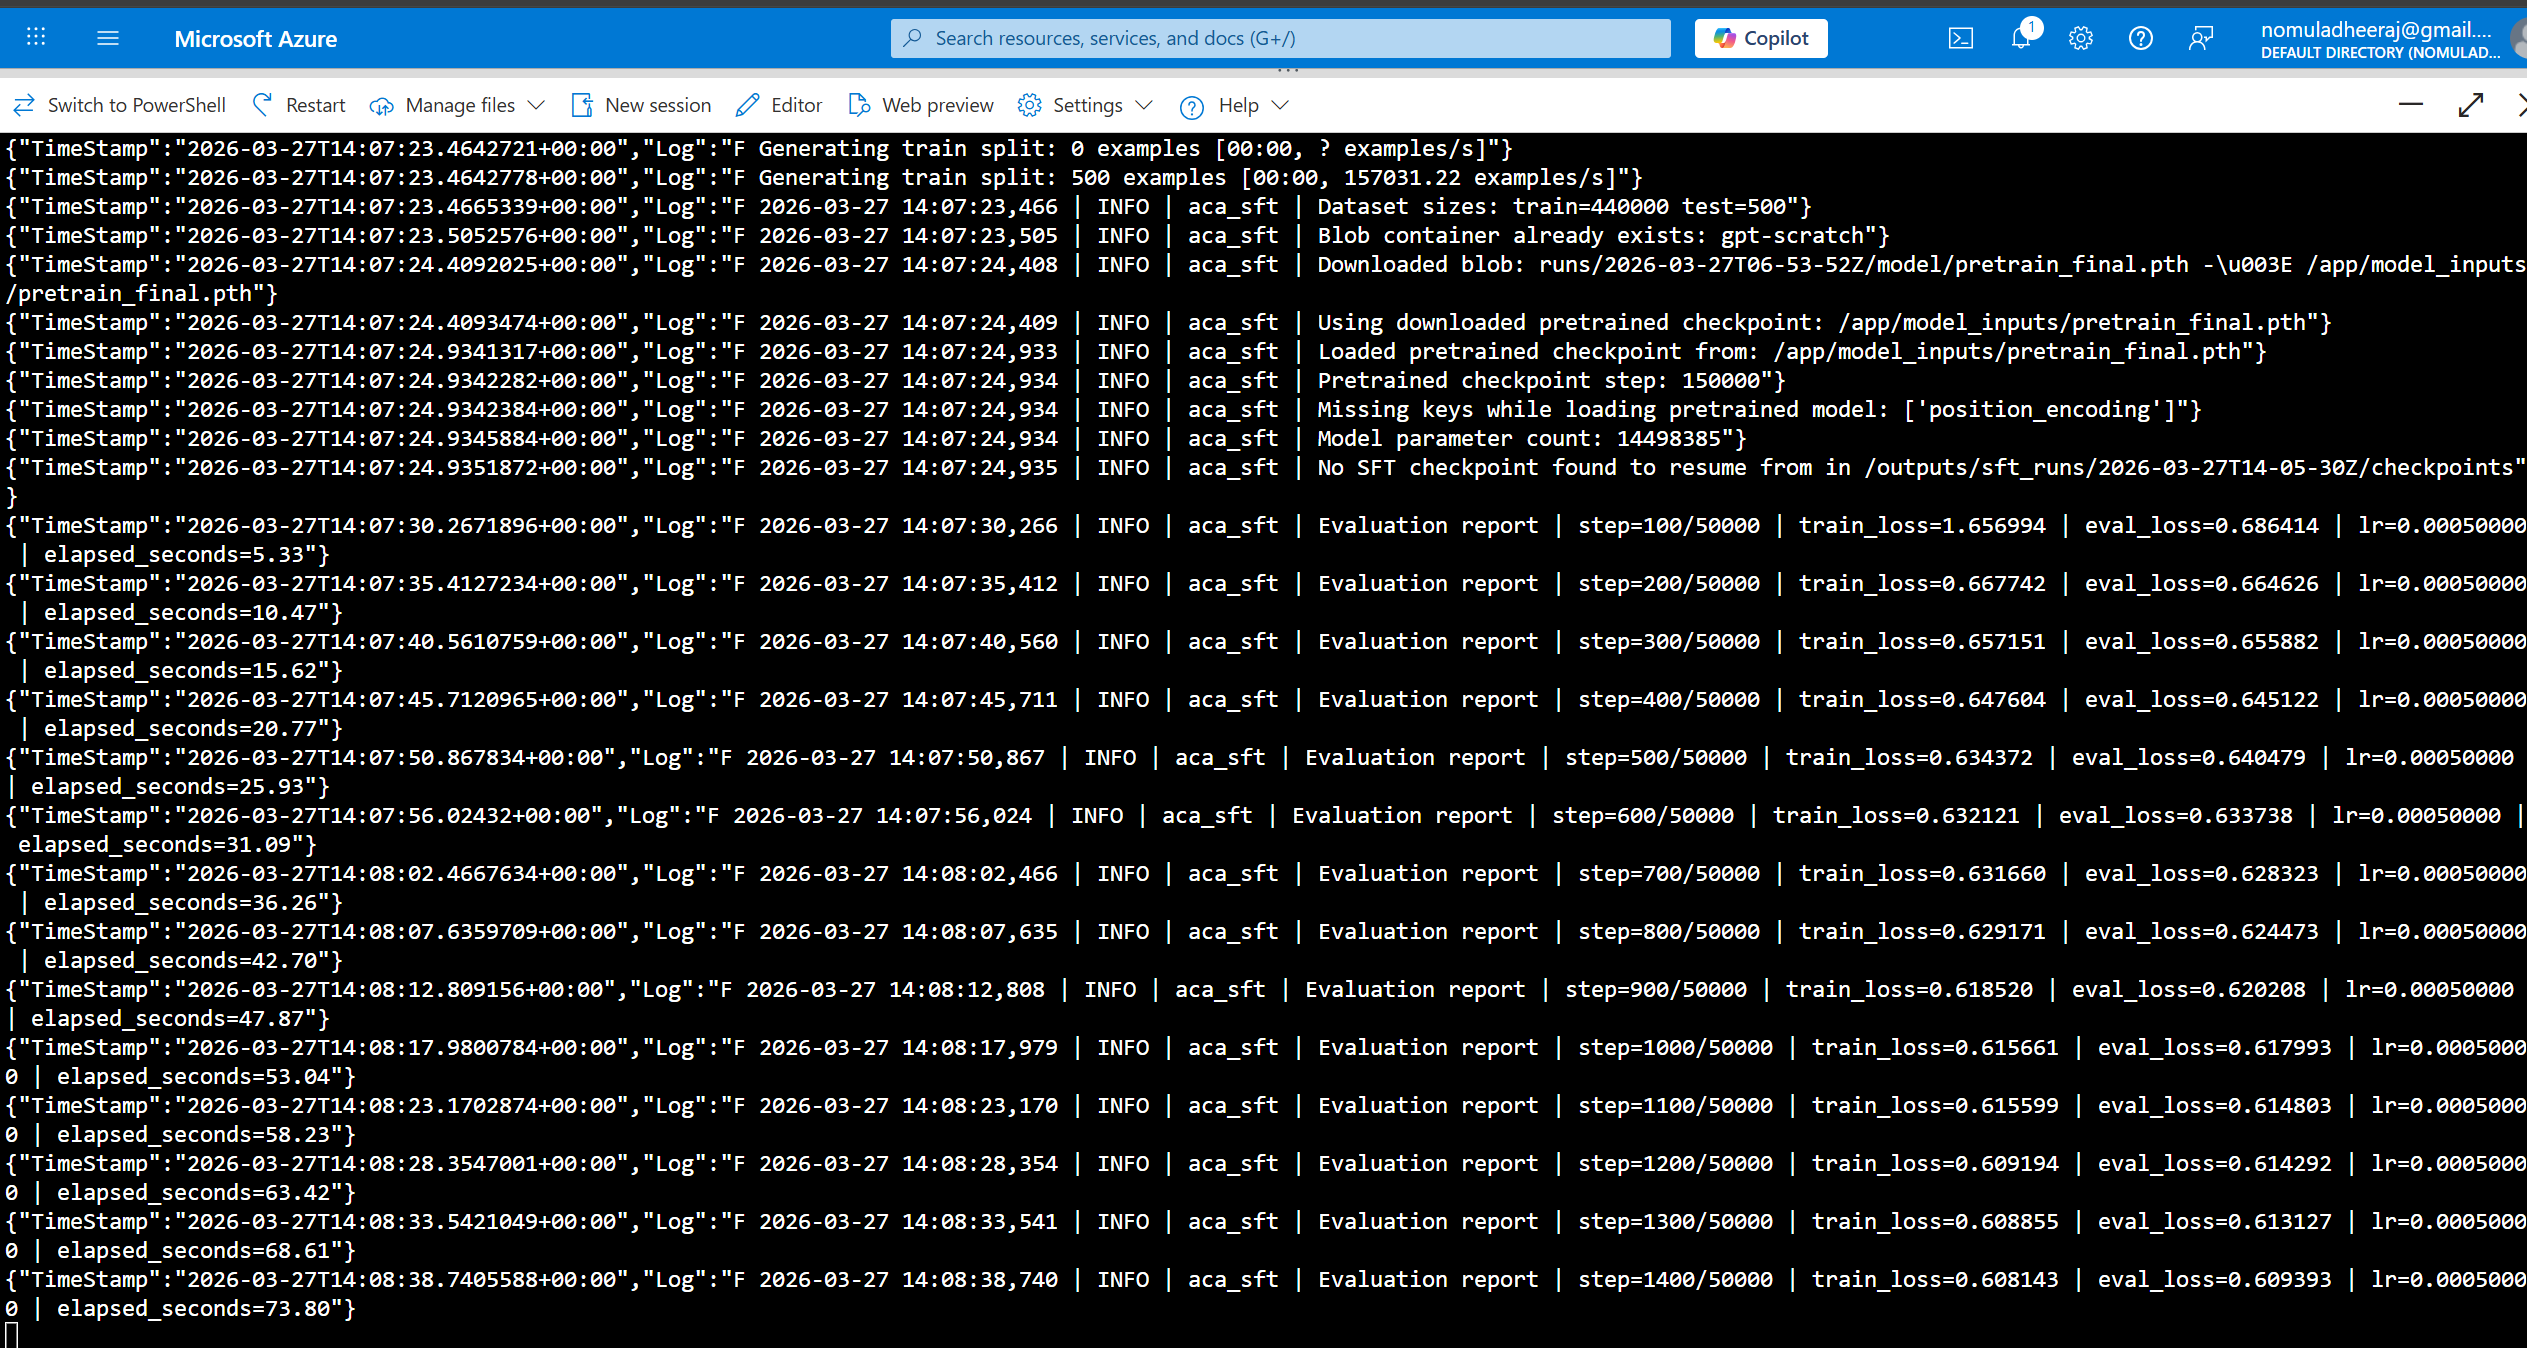

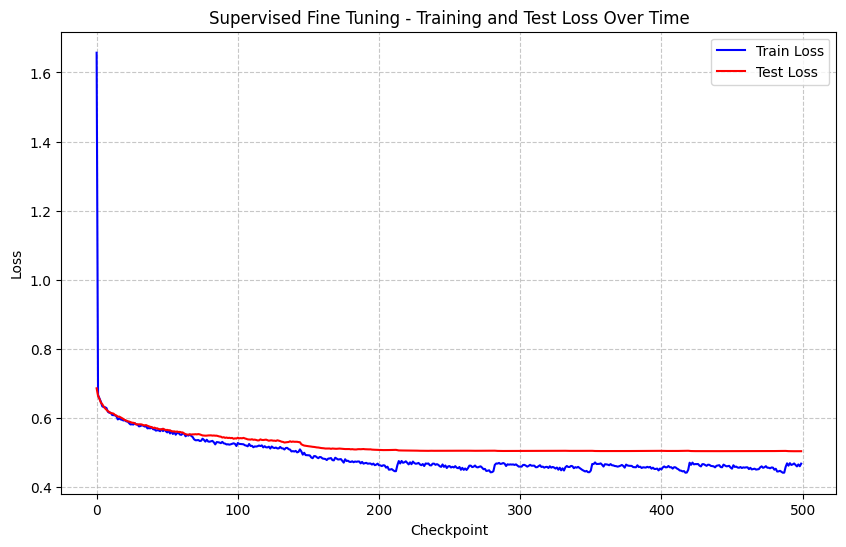

In [31]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

model_run_dir = Path(r"C:\Users\deril\OneDrive\Desktop\Deril\Development\Transformers-From-Scratch\aca_sft\model_run")
metrics_path = model_run_dir / "metrics" / "metrics.json"
loss_curve_path = model_run_dir / "metrics" / "sft_loss_curve.png"

use_existing_model = metrics_path.exists()

if not use_existing_model:
    raise FileNotFoundError(f"Could not find metrics file at {metrics_path}")

with open(metrics_path, "r", encoding="utf-8") as f:
    metrics = json.load(f)

losses = [item["loss"] for item in metrics["train_losses"]]
test_losses = [item["loss"] for item in metrics["eval_losses"]]

if loss_curve_path.exists():
    print("Existing model used, showing saved SFT loss curve.")
    plt.figure(figsize=(10, 6))
    plt.imshow(plt.imread(loss_curve_path))
    plt.axis("off")
else:
    plt.figure(figsize=(10, 6))
    plt.plot(losses, label="Train Loss", color="blue")
    plt.plot(test_losses, label="Test Loss", color="red")
    plt.xlabel("Checkpoint")
    plt.ylabel("Loss")
    plt.title("Supervised Fine Tuning - Training and Test Loss Over Time")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()
    plt.show()


#### 1.7.1 SFT Inference

In [32]:
def sft_inference(prompt,torch_model, max_new_tokens):
    torch_model.eval()
    prompt = "<Question>" + prompt + "</Question>" + "<Answer>" # Wrap the prompt in <Question> and start inference with <Answer>
    with torch.no_grad(): 
        tokens = hf_tokenizer.encode(prompt) # Tokenize the prompt
        for _ in range(max_new_tokens):
            if tokens[-1] == hf_tokenizer.eos_token_id: # Stop if we reach the end of the sequence
                break
            num_tokens = len(tokens) # 
            tokens_padded = tokens + [hf_tokenizer.eos_token_id] * (config.seq_len - num_tokens) # pad the sequence with eos token
            tokens_padded = torch.tensor(tokens_padded).unsqueeze(0).to(device) 
            logits = torch_model(tokens_padded) # Forward pass through the model
            probabilities = torch.softmax(logits[0, num_tokens-1, :], dim=-1) # Get the probabilities of the last token
            predicted_token = torch.argmax(probabilities).item() # Greedy decoding, change to sampling for more diversity
            tokens.append(predicted_token)
        
        # Strip the text to between the <Answer></Answer> tags
        full_answer = hf_tokenizer.decode(tokens)
        answer_start = full_answer.find("<Answer>") + len("<Answer>")
        answer_end = full_answer.find("</Answer>")
        return full_answer[answer_start:answer_end]

In [33]:
print("Predicted:", sft_inference("Who is the most powerful leader in the west?", model, max_new_tokens=20))
print("Predicted:", sft_inference("What color is the sun?", model, max_new_tokens=20))
print("Predicted:", sft_inference("What color is the ocean", model, max_new_tokens=20))
print("Predicted:", sft_inference("How many planets are in the solar system", model, max_new_tokens=20))
print("Predicted:", sft_inference("What three countries are in north america?", model, max_new_tokens=20))
print("Predicted:", sft_inference("How many eyes do humans have?", model, max_new_tokens=20))

Predicted: Theodore Roosevelt
Predicted: Yellow
Predicted: Red
Predicted: No
Predicted: Brazil, Brazil, and the United States
Predicted: Two


#### 1.7.2 Pretrained vs SFT Comparison

The cells below load the final pretrained model and the final SFT model downloaded from Blob, then compare their generations side by side on the same prompts.


In [34]:
from pathlib import Path
import torch

pretrain_model_path = Path(r"C:\Users\deril\OneDrive\Desktop\Deril\Development\Transformers-From-Scratch\aca_pretraining\model_run\model\pretrain_final.pth")
sft_model_path = Path(r"C:\Users\deril\OneDrive\Desktop\Deril\Development\Transformers-From-Scratch\aca_sft\model_run\model\sft_final.pth")

def load_checkpoint_model(model_path):
    checkpoint = torch.load(model_path, map_location=device)
    saved_config = checkpoint["model_config"]
    loaded_config = GPTConfig(
        vocab_size=saved_config["vocab_size"],
        seq_len=saved_config["seq_len"],
        n_layer=saved_config["n_layer"],
        n_head=saved_config["n_head"],
        n_embd=saved_config["n_embd"],
    )

    loaded_model = GPTModel(loaded_config).to(device)
    state_dict = checkpoint["model_state_dict"].copy()
    state_dict.pop("position_encoding", None)
    loaded_model.load_state_dict(state_dict, strict=False)
    loaded_model.eval()
    return loaded_model, loaded_config, checkpoint

pretrained_model, pretrained_config, pretrained_checkpoint = load_checkpoint_model(pretrain_model_path)
sft_model, sft_config, sft_checkpoint = load_checkpoint_model(sft_model_path)

print(f"Loaded pretrained model from: {pretrain_model_path}")
print(f"Pretrained step: {pretrained_checkpoint.get('step')}")
print(f"Loaded SFT model from: {sft_model_path}")
print(f"SFT step: {sft_checkpoint.get('step')}")


Loaded pretrained model from: C:\Users\deril\OneDrive\Desktop\Deril\Development\Transformers-From-Scratch\aca_pretraining\model_run\model\pretrain_final.pth
Pretrained step: 150000
Loaded SFT model from: C:\Users\deril\OneDrive\Desktop\Deril\Development\Transformers-From-Scratch\aca_sft\model_run\model\sft_final.pth
SFT step: 50000


In [35]:
comparison_prompts = [
    "The president signed a bill to pass",
    "Reports are showing that",
    "Who is the most powerful leader in the west?",
    "What color is the sun?",
]

for prompt in comparison_prompts:
    print('=' * 100)
    print(f"Prompt: {prompt}")
    print()
    print('Pretrained:')
    print(inference(prompt, pretrained_model, max_new_tokens=20))
    print()
    print('SFT:')
    print(sft_inference(prompt, sft_model, max_new_tokens=20))
    print()


Prompt: The president signed a bill to pass

Pretrained:
The president signed a bill to pass leather SodaStream Brave Cookies Clah on Sunday, allowing me access the product straight into his restaurant,"

SFT:
No

Prompt: Reports are showing that

Pretrained:
Reports are showing that many young children have older people say lived with him and their background. "They did not know,"

SFT:
No

Prompt: Who is the most powerful leader in the west?

Pretrained:
Who is the most powerful leader in the west? Open leaders say she won't be disappointed on Saturday after setting a "UN Boards rating." "I

SFT:
Theodore Roosevelt

Prompt: What color is the sun?

Pretrained:
What color is the sun? They show it really isn't going to spill and do anything. I know what that is not that

SFT:
Yellow



In [36]:
def sft_inference(prompt, torch_model, max_new_tokens, temperature=0.8, top_k=20, min_new_tokens=3, debug=False):
    torch_model.eval()
    prompt = "<Question>" + prompt + "</Question>" + "<Answer>"

    with torch.no_grad():
        tokens = hf_tokenizer.encode(prompt)

        for step in range(max_new_tokens):
            if len(tokens) >= config.seq_len:
                tokens = tokens[-config.seq_len:]

            num_tokens = len(tokens)
            tokens_padded = tokens + [hf_tokenizer.eos_token_id] * (config.seq_len - num_tokens)
            tokens_padded = torch.tensor(tokens_padded).unsqueeze(0).to(device)

            logits = torch_model(tokens_padded)
            next_token_logits = logits[0, num_tokens - 1, :] / temperature

            if top_k is not None:
                top_k_values, top_k_indices = torch.topk(next_token_logits, top_k)
                probs = torch.softmax(top_k_values, dim=-1)
                predicted_token = top_k_indices[torch.multinomial(probs, 1).item()].item()
            else:
                probs = torch.softmax(next_token_logits, dim=-1)
                predicted_token = torch.multinomial(probs, 1).item()

            if step < min_new_tokens and predicted_token == hf_tokenizer.eos_token_id:
                continue

            tokens.append(predicted_token)

            if predicted_token == hf_tokenizer.eos_token_id:
                break

        full_text = hf_tokenizer.decode(tokens)

        if debug:
            print("FULL TEXT:", full_text)

        answer_start = full_text.find("<Answer>")
        answer_end = full_text.find("</Answer>")

        if answer_start != -1:
            answer_start += len("<Answer>")
        else:
            answer_start = 0

        if answer_end == -1:
            answer_end = len(full_text)

        return full_text[answer_start:answer_end].strip()


In [37]:
print("Predicted:", sft_inference("Who is the most powerful leader in the west?", model, max_new_tokens=30, debug=True))
print("Predicted:", sft_inference("What color is the sun?", model, max_new_tokens=30, debug=True))
print("Predicted:", sft_inference("What three countries are in north america?", model, max_new_tokens=30, debug=True))


FULL TEXT: <Question>Who is the most powerful leader in the west?</Question><Answer>The President of the United States</Answer><|endoftext|>
Predicted: The President of the United States
FULL TEXT: <Question>What color is the sun?</Question><Answer>Dark blue</Answer><|endoftext|>
Predicted: Dark blue
FULL TEXT: <Question>What three countries are in north america?</Question><Answer>Souches and Peru</Answer><|endoftext|>
Predicted: Souches and Peru
